# ML-04 — Search Intelligence Data Contract

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maalaaikaa/flyrank-ml-internship/blob/main/work/notebooks/w03_data_contract.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### 1. Unit of analysis and time window

One row represents one anonymized content item for one client.

The dataset is used for content refresh prioritization. The prediction target is `trend_pct`, representing the observed percentage trend associated with the content item.

The available preview does not show a dedicated date column, so I will not claim a specific calendar start or end date without verifying it from the dataset. The time window should therefore be treated as the observation window represented by the source dataset rather than an invented date range.

The prediction is intended as decision-support: content with a more negative observed trend can be considered a stronger candidate for refresh.

In [12]:
import pandas as pd

# Load the dataset from GitHub
url = "https://raw.githubusercontent.com/maalaaikaa/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [13]:
# Check the dataset grain and possible date/time fields

print("Number of rows:", len(df))
print("Number of columns:", len(df))
print("\nColumn names:")
print(df.columns.tolist())

# Look for possible date/time columns
date_keywords = ["date", "time", "month", "week", "day", "period"]

possible_date_cols = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in date_keywords)
]

print("\nPossible date/time columns:")
print(possible_date_cols)

# Check whether content_id is unique
if "content_id" in df.columns:
    print("\nUnique content_id values:", df["content_id"].nunique())
    print("Total rows:", len(df))
    print("Is content_id unique?", df["content_id"].is_unique)

# Basic grain check
print("\nDataset grain check:")
print("One row = one content record:", len(df) == len(df.drop_duplicates()))

Number of rows: 30000
Number of columns: 30000

Column names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

Possible date/time columns:
['days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update']

Unique content_id values: 30000
Total rows:

## 2. Fields: feature / label / context / excluded

### Field buckets

**Label**

- `trend_pct` — the target variable. It represents the observed percentage trend that the model will predict.

**Features**

The candidate features are the non-identifier content, search, competition, cost, and engagement fields that are available before the prediction decision. Examples visible in the dataset include:

- `search_volume`
- `competition`
- `competition_level`
- `cpc`
- `content_type`
- `main_intent`
- `word_count`
- `char_count`
- `ctr`
- `avg_position`
- `engagement_rate`
- `scroll_rate`
- `ai_traffic_pct`

**Context**

- `content_id` can be retained as a record identifier for tracing rows, but it is not used as a model feature.
- `client_id` can identify the client associated with a record, but it is not used as a model feature.

**Excluded**

- `trend_direction` — excluded because it appears to be a categorical representation of the same trend information contained in `trend_pct`, creating target leakage.
- Tier/bucket fields such as `char_count_tier`, `impression_tier`, and `position_tier` are excluded when they duplicate information represented by the underlying numeric variables.
- Identifier fields are excluded from model features because they do not represent generalizable content characteristics.

The final feature set must only contain information that would be available before making the refresh-prioritization prediction.

In [14]:
# Define the label
label = "trend_pct"

# Context fields: useful for identifying/grouping records,
# but not used as predictive features
context_cols = [
    col for col in ["content_id", "client_id"]
    if col in df.columns
]

# Known leakage / duplicate representation fields
excluded_cols = [
    col for col in [
        "trend_direction",
        "char_count_tier",
        "impression_tier",
        "position_tier"
    ]
    if col in df.columns
]

# Safety check: label must exist
assert label in df.columns, f"Missing target column: {label}"

# Candidate feature columns
feature_cols = [
    col for col in df.columns
    if col not in context_cols
    and col not in excluded_cols
    and col != label
]

print("LABEL")
print(label)

print("\nCONTEXT")
print(context_cols)

print("\nEXCLUDED")
print(excluded_cols)

print("\nFEATURES")
print(feature_cols)

print("\nCounts")
print("Total columns:", len(df.columns))
print("Features:", len(feature_cols))
print("Context:", len(context_cols))
print("Excluded:", len(excluded_cols))
print("Label:", 1)

# Every column should belong to exactly one bucket
all_bucketed = set(feature_cols) | set(context_cols) | set(excluded_cols) | {label}

assert all_bucketed == set(df.columns), \
    "Some dataset columns were not assigned to a bucket."

print("\nAll dataset columns have been assigned to a bucket.")


LABEL
trend_pct

CONTEXT
['content_id', 'client_id']

EXCLUDED
['trend_direction', 'char_count_tier', 'impression_tier', 'position_tier']

FEATURES
['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Counts
Total columns: 44
Features: 37
Context: 2
Excluded: 4
Label: 1

All dataset columns have been assigned to a bucket.


## 3. Verify it with queries (grain, counts, missing values, windows)
### Verify the contract

The checks below verify the main contract claims:

1. The dataset has one row per `content_id`.
2. The target `trend_pct` exists and contains numeric observations.
3. Missing values are measured for all fields.
4. The dataset does not provide an explicit observation-date field in the inspected schema, so a calendar window is not claimed.
5. The target distribution is inspected to understand the observed range.
6. The excluded `trend_direction` field is compared with `trend_pct` to check for target leakage.

In [15]:
# 1. Grain / row count check

print("=== GRAIN CHECK ===")

print("Rows:", len(df))
print("Columns:", len(df.columns))

if "content_id" in df.columns:
    print("Unique content_id:", df["content_id"].nunique())
    print("Duplicate content_id:", df["content_id"].duplicated().sum())

    assert df["content_id"].nunique() == len(df), \
        "content_id is not unique."


# 2. Target check

print("\n=== TARGET CHECK ===")

print("Target:", label)
print("Target dtype:", df[label].dtype)
print("Target missing:", df[label].isna().sum())
print("Target non-missing:", df[label].notna().sum())

print("\nTarget summary:")
print(df[label].describe())


# 3. Missing-value check

print("\n=== MISSING VALUE CHECK ===")

missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

print(missing_summary)


# 4. Schema/date-window check

print("\n=== DATE / WINDOW CHECK ===")

date_like_cols = [
    col for col in df.columns
    if any(word in col.lower()
           for word in ["date", "time", "timestamp", "month", "year"])
]

print("Possible date/time columns:", date_like_cols)

if len(date_like_cols) == 0:
    print(
        "No explicit date/time field was found using the schema check; "
        "therefore no calendar start/end window is claimed."
    )


# 5. Leakage check

print("\n=== TREND LEAKAGE CHECK ===")

if "trend_direction" in df.columns:

    trend_check = (
        df.groupby("trend_direction")[label]
          .agg(["count", "min", "mean", "max"])
          .sort_values("mean")
    )

    print(trend_check)

=== GRAIN CHECK ===
Rows: 30000
Columns: 44
Unique content_id: 30000
Duplicate content_id: 0

=== TARGET CHECK ===
Target: trend_pct
Target dtype: float64
Target missing: 3388
Target non-missing: 26612

Target summary:
count    26612.000000
mean        -4.785969
std        473.861780
min       -100.000000
25%        -62.600000
50%        -33.500000
75%          0.000000
max      44900.000000
Name: trend_pct, dtype: float64

=== MISSING VALUE CHECK ===
provider_used             21438
word_count                 7699
char_count                 7699
word_count_tier            7699
char_count_tier            7699
model_used                 5733
trend_pct                  3388
competition_level          2610
search_volume              2468
cpc                        2468
competition                2468
main_intent                2374
scroll_rate                 125
content_type                  0
client_id                     0
content_id                    0
impressions_90d               0


In [16]:
# Numeric target and range verification

assert pd.api.types.is_numeric_dtype(df[label]), \
    f"{label} should be numeric for regression."

print("Minimum trend_pct:", df[label].min())
print("Maximum trend_pct:", df[label].max())
print("Mean trend_pct:", df[label].mean())
print("Median trend_pct:", df[label].median())

Minimum trend_pct: -100.0
Maximum trend_pct: 44900.0
Mean trend_pct: -4.785968735908612
Median trend_pct: -33.5


<Figure size 800x500 with 0 Axes>

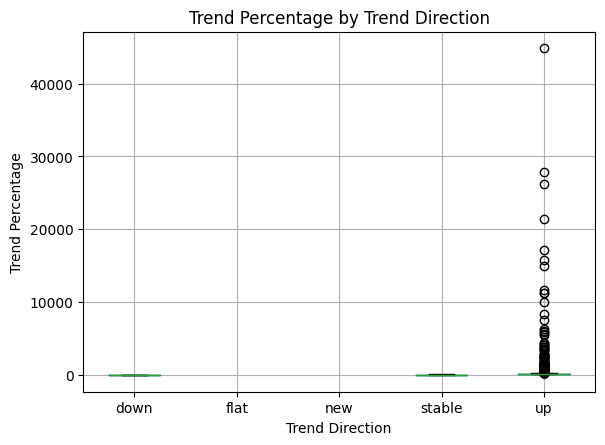

In [17]:
import matplotlib.pyplot as plt

if "trend_direction" in df.columns:

    plt.figure(figsize=(8, 5))

    df.boxplot(
        column="trend_pct",
        by="trend_direction"
    )

    plt.title("Trend Percentage by Trend Direction")
    plt.suptitle("")
    plt.xlabel("Trend Direction")
    plt.ylabel("Trend Percentage")

    plt.show()

## 4. Data limits



This dataset supports directional and decision-support analysis, but it cannot answer every question about why content performance changed.

First, the inspected schema does not provide a clear calendar date field, so this analysis cannot establish a precise start and end date for the observations.

Second, the dataset is observational. A negative `trend_pct` can indicate declining performance, but it does not prove that a particular content change caused the decline.

Third, search and engagement metrics may represent different measurement windows. Without a documented time boundary for every metric, the analysis should not assume that all fields were measured over exactly the same period.

Fourth, the dataset may contain missing values. Missing values are measured rather than silently treated as zero.

Fifth, client and content identifiers are anonymized and are used only as context. The model should not be interpreted as learning private client identity.

Finally, `trend_direction` is not used as a feature because it is closely derived from the target `trend_pct`. Including it could leak information about the answer the model is supposed to predict.

Therefore, the resulting model should be treated as decision-support for prioritizing content for review, not as proof that a page must be refreshed or that refreshing it will cause a specific improvement.

In [18]:
# Final contract self-check

print("=== FINAL DATA CONTRACT CHECK ===")

assert label == "trend_pct"
assert label in df.columns

assert "trend_direction" not in feature_cols

for col in context_cols:
    assert col not in feature_cols

for col in excluded_cols:
    assert col not in feature_cols

assert set(feature_cols) | set(context_cols) | set(excluded_cols) | {label} == set(df.columns)

print("✓ Target exists:", label)
print("✓ Target is not included as a feature")
print("✓ trend_direction is excluded from features")
print("✓ Context columns are excluded from features")
print("✓ All dataset columns are assigned to a bucket")
print("✓ Contract checks completed successfully")

=== FINAL DATA CONTRACT CHECK ===
✓ Target exists: trend_pct
✓ Target is not included as a feature
✓ trend_direction is excluded from features
✓ Context columns are excluded from features
✓ All dataset columns are assigned to a bucket
✓ Contract checks completed successfully


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.